In [90]:
import pandas as pd
import numpy as np
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score
)

In [106]:
project_path = Path("/Users/irinafendley/Projects/Loan_Default")

data_path = project_path / "data/processed/loan_clean.csv"

df = pd.read_csv(data_path)

In [107]:
df = df.drop("LoanID", axis=1)

df["Income_to_Loan"] = df["Income"] / (df["LoanAmount"] + 1)
df["Debt_burden"] = df["LoanAmount"] / (df["Income"] + 1)
df["Score_pressure"] = df["LoanAmount"] / (df["CreditScore"] + 1)
df["Risk_rate"] = df["InterestRate"] * df["DTIRatio"]
df["Risk_score"] = df["InterestRate"] * 2 + df["DTIRatio"] * 2


X = df.drop("Default", axis=1)
y = df["Default"]

In [108]:
X = pd.get_dummies(X, drop_first=True)

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [111]:
model = LogisticRegression(
    max_iter=2000
)

model.fit(X_train, y_train)

/Users/irinafendley/Projects/Loan_Default/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [112]:
y_proba = model.predict_proba(X_test)[:, 1]

In [113]:
pd.DataFrame({
    "Actual_Default": y_test,
    "Probability_of_Default": y_proba
}).head(10)

,Actual_Default,Probability_of_Default
211648,0,0.033687
201101,0,0.023018
140423,0,0.062984
204530,0,0.089376
166481,0,0.096367
239445,0,0.012154
127976,0,0.377431
124925,0,0.029066
26516,1,0.299401
82635,0,0.194437


In [114]:
best_threshold = 0.7

y_pred_final = (
    y_proba > best_threshold
).astype(int)

print(f"Threshold: {best_threshold}")

print(classification_report(
    y_test,
    y_pred_final
))

print(confusion_matrix(
    y_test,
    y_pred_final
))

Threshold: 0.7
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.77      0.01      0.03      5931

    accuracy                           0.88     51070
   macro avg       0.83      0.51      0.48     51070
weighted avg       0.87      0.88      0.83     51070

[[45116    23]
 [ 5854    77]]


In [115]:
print("Accuracy:", accuracy_score(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_proba))

Accuracy: 0.8849226551791658

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.77      0.01      0.03      5931

    accuracy                           0.88     51070
   macro avg       0.83      0.51      0.48     51070
weighted avg       0.87      0.88      0.83     51070


Confusion Matrix:
[[45116    23]
 [ 5854    77]]

ROC-AUC:
0.7512545009390783


In [116]:
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_proba > t).astype(int)
    print("Threshold:", t)
    print(classification_report(y_test, y_pred))

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.91      0.95      0.93     45139
           1       0.40      0.24      0.30      5931

    accuracy                           0.87     51070
   macro avg       0.65      0.60      0.61     51070
weighted avg       0.85      0.87      0.86     51070

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     45139
           1       0.51      0.13      0.20      5931

    accuracy                           0.88     51070
   macro avg       0.70      0.56      0.57     51070
weighted avg       0.85      0.88      0.85     51070

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.58      0.06      0.11      5931

    accuracy                           0.89     51070
   macro avg       0.74      0.53      0.53     51070
weighted avg       0.85      

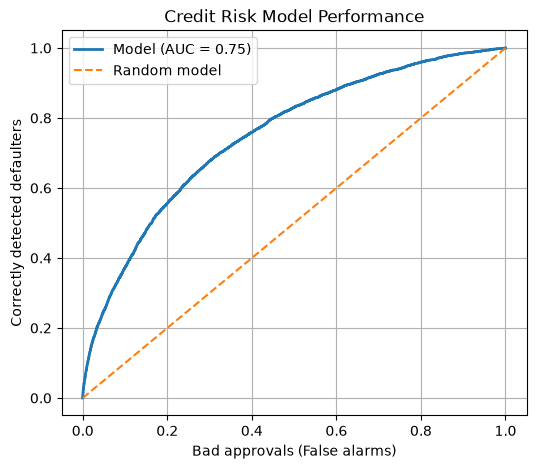

In [117]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"Model (AUC = {roc_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], "--", label="Random model")

plt.title("Credit Risk Model Performance")
plt.xlabel("Bad approvals (False alarms)")
plt.ylabel("Correctly detected defaulters")

plt.legend()
plt.grid()
plt.show()

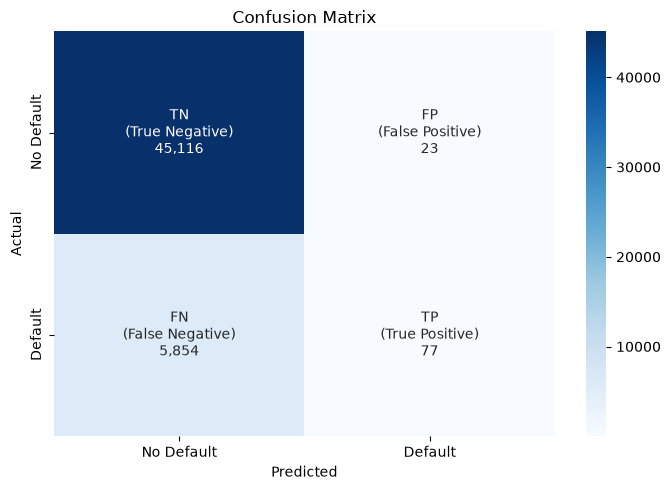

In [118]:
cm = confusion_matrix(y_test, y_pred_final)

labels = np.array([
    ["TN\n(True Negative)", "FP\n(False Positive)"],
    ["FN\n(False Negative)", "TP\n(True Positive)"]
])

annot = np.empty_like(labels, dtype=object)

for i in range(2):
    for j in range(2):
        annot[i, j] = f"{labels[i,j]}\n{cm[i,j]:,}"

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=annot,
    fmt="",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0.5, 1.5], ["No Default", "Default"])
plt.yticks([0.5, 1.5], ["No Default", "Default"])

plt.tight_layout()
plt.show()

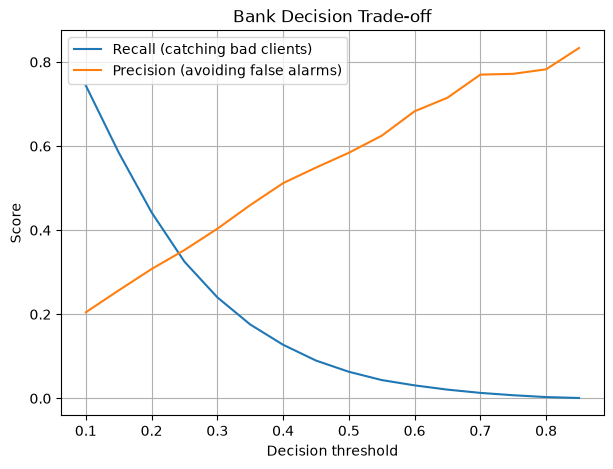

In [119]:
thresholds = np.arange(0.1, 0.9, 0.05)

recall_list = []
precision_list = []

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    recall_list.append(recall_score(y_test, y_pred_t))
    precision_list.append(precision_score(y_test, y_pred_t))

plt.figure(figsize=(7, 5))

plt.plot(thresholds, recall_list, label="Recall (catching bad clients)")
plt.plot(thresholds, precision_list, label="Precision (avoiding false alarms)")

plt.title("Bank Decision Trade-off")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

In [120]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Impact on Risk": model.coef_[0]
})

feature_importance["Absolute Impact"] = feature_importance["Impact on Risk"].abs()

feature_importance = feature_importance.sort_values(
    "Absolute Impact",
    ascending=False
)

feature_importance.head(15)

,Feature,Impact on Risk,Absolute Impact
13,Debt_burden,0.193600,0.193600
5,NumCreditLines,0.044750,0.044750
0,Age,-0.044261,0.044261
11,HasCoSigner,-0.035560,0.035560
10,HasDependents,-0.034282,0.034282
22,EmploymentType_Unemployed,0.025838,0.025838
12,Income_to_Loan,0.025664,0.025664
15,Risk_rate,0.022814,0.022814
16,Risk_score,0.021883,0.021883
9,HasMortgage,-0.021808,0.021808


In [105]:
import joblib

model_path = project_path / "data/models/logistic_regression.pkl"

joblib.dump(model, model_path)

['/Users/irinafendley/Projects/Loan_Default/data/models/logistic_regression.pkl']